# Projeto 1 - EDA DataSUS: Morbidade Hospitalar no Amazonas

Este notebook faz uma análise exploratória dos dados de Morbidade Hospitalar do SUS (SIH/SUS) para o estado do Amazonas, obtidos via TABNET/DataSUS.

Fonte principal: [DATASUS - Morbidade Hospitalar do SUS (SIH/SUS)](https://datasus.saude.gov.br/acesso-a-informacao/morbidade-hospitalar-do-sus-sih-sus/).

Os CSVs em `data/raw/` foram baixados com `scripts/download_tabnet.py`, usando o formulário TABNET de morbidade hospitalar por local de residência para Amazonas.

## Objetivos

- Limpar dados exportados do TABNET, tratando valores nulos, tipos incorretos, totais e entidades HTML.
- Analisar internações por município, faixa etária, ano e mortalidade hospitalar.
- Medir concentração territorial, crescimento e grupos de maior risco.
- Visualizar padrões com Seaborn/Matplotlib e exportar gráficos para o README.
- Registrar uma conclusão interpretativa e tecnicamente cautelosa: **O que os dados revelam?**

In [1]:
from pathlib import Path
import html

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titleweight"] = "bold"

def formatar_inteiro(valor: float) -> str:
    return f"{valor:,.0f}".replace(",", ".")


def formatar_percentual(valor: float) -> str:
    return f"{valor:.1f}%".replace(".", ",")


PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

RAW_DIR

WindowsPath('C:/Users/Usuario/Documents/New project 2/eda-datasus-amazonas/data/raw')

## Carregamento e limpeza

Os arquivos do TABNET vêm com metadados iniciados por `#`, nomes com entidades HTML e alguns valores ausentes representados por `-`. A função abaixo padroniza esses pontos e transforma as tabelas largas por ano em formato longo.

In [2]:
def normalizar_valor(serie: pd.Series) -> pd.Series:
    return pd.to_numeric(
        serie.astype(str)
        .str.strip()
        .str.replace("-", "0", regex=False)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False),
        errors="coerce",
    )


def carregar_tabnet(nome_arquivo: str, dimensao: str, valor_nome: str) -> pd.DataFrame:
    caminho = RAW_DIR / nome_arquivo
    df = pd.read_csv(caminho, comment="#", encoding="utf-8-sig")
    df.columns = [html.unescape(str(col)).strip() for col in df.columns]
    df = df.rename(columns={df.columns[0]: dimensao})
    df[dimensao] = df[dimensao].map(lambda x: html.unescape(str(x)).strip())

    df = df[~df[dimensao].str.upper().eq("TOTAL")].copy()
    anos = [col for col in df.columns if str(col).isdigit()]

    longo = df.melt(
        id_vars=dimensao,
        value_vars=anos,
        var_name="ano",
        value_name=valor_nome,
    )
    longo["ano"] = longo["ano"].astype(int)
    longo[valor_nome] = normalizar_valor(longo[valor_nome]).fillna(0)
    return longo


internacoes_municipio = carregar_tabnet(
    "internacoes_municipio_ano_am.csv",
    dimensao="municipio_raw",
    valor_nome="internacoes",
)
obitos_municipio = carregar_tabnet(
    "obitos_municipio_ano_am.csv",
    dimensao="municipio_raw",
    valor_nome="obitos",
)
internacoes_faixa = carregar_tabnet(
    "internacoes_faixa_etaria_ano_am.csv",
    dimensao="faixa_etaria",
    valor_nome="internacoes",
)
taxa_faixa = carregar_tabnet(
    "taxa_mortalidade_faixa_etaria_ano_am.csv",
    dimensao="faixa_etaria",
    valor_nome="taxa_mortalidade",
)
populacao_municipio = pd.read_csv(RAW_DIR / "populacao_municipios_am.csv", dtype={"codigo_municipio": str})

internacoes_municipio.head()

,municipio_raw,ano,internacoes
0,130002 ALVARAES,2020,12
1,130006 AMATURA,2020,9
2,130008 ANAMA,2020,8
3,130010 ANORI,2020,18
4,130014 APUI,2020,8


In [3]:
def separar_codigo_municipio(df: pd.DataFrame) -> pd.DataFrame:
    saida = df.copy()
    extraido = saida["municipio_raw"].str.extract(r"^(?P<codigo_municipio>\d{6})\s+(?P<municipio>.+)$")
    saida["codigo_municipio"] = extraido["codigo_municipio"]
    saida["municipio"] = extraido["municipio"].fillna(saida["municipio_raw"]).str.title()
    return saida.drop(columns=["municipio_raw"])


internacoes_municipio = separar_codigo_municipio(internacoes_municipio)
obitos_municipio = separar_codigo_municipio(obitos_municipio)

faixa_ordem = [
    "Menor 1 ano",
    "1 a 4 anos",
    "5 a 9 anos",
    "10 a 14 anos",
    "15 a 19 anos",
    "20 a 29 anos",
    "30 a 39 anos",
    "40 a 49 anos",
    "50 a 59 anos",
    "60 a 69 anos",
    "70 a 79 anos",
    "80 anos e mais",
    "Idade ignorada",
]

for df in [internacoes_faixa, taxa_faixa]:
    df["faixa_etaria"] = pd.Categorical(df["faixa_etaria"], categories=faixa_ordem, ordered=True)

# A consulta usa arquivos de processamento de Jan/2021 a Fev/2026. Como 2026 está incompleto,
# a análise anual principal usa anos completos de atendimento: 2021 a 2025.
anos_analise = list(range(2021, 2026))

internacoes_municipio = internacoes_municipio[internacoes_municipio["ano"].isin(anos_analise)].copy()
obitos_municipio = obitos_municipio[obitos_municipio["ano"].isin(anos_analise)].copy()
internacoes_faixa = internacoes_faixa[internacoes_faixa["ano"].isin(anos_analise)].copy()
taxa_faixa = taxa_faixa[taxa_faixa["ano"].isin(anos_analise)].copy()

dados_municipio = internacoes_municipio.merge(
    obitos_municipio,
    on=["codigo_municipio", "municipio", "ano"],
    how="left",
)
dados_municipio["obitos"] = dados_municipio["obitos"].fillna(0)
dados_municipio["taxa_mortalidade"] = np.where(
    dados_municipio["internacoes"] > 0,
    dados_municipio["obitos"] / dados_municipio["internacoes"] * 100,
    0,
)
populacao_municipio = populacao_municipio[populacao_municipio["ano"].isin(anos_analise)].copy()
dados_municipio = dados_municipio.merge(
    populacao_municipio[["codigo_municipio", "ano", "populacao", "fonte_populacao"]],
    on=["codigo_municipio", "ano"],
    how="left",
)
dados_municipio["internacoes_por_100k"] = (
    dados_municipio["internacoes"] / dados_municipio["populacao"] * 100_000
)
dados_municipio["obitos_por_100k"] = (
    dados_municipio["obitos"] / dados_municipio["populacao"] * 100_000
)

dados_municipio.head()

,ano,internacoes,codigo_municipio,municipio,obitos,taxa_mortalidade,populacao,fonte_populacao,internacoes_por_100k,obitos_por_100k
0,2021,681,130002,Alvaraes,18,2.643172,16396,IBGE - Estimativas de populacao,4153.452061,109.782874
1,2021,362,130006,Amatura,6,1.657459,11934,IBGE - Estimativas de populacao,3033.350092,50.276521
2,2021,649,130008,Anama,5,0.770416,14292,IBGE - Estimativas de populacao,4541.001959,34.984607
3,2021,818,130010,Anori,13,1.589242,21937,IBGE - Estimativas de populacao,3728.859917,59.260610
4,2021,1035,130014,Apui,24,2.318841,22739,IBGE - Estimativas de populacao,4551.651348,105.545539


### Checagem de qualidade

Aqui verificamos nulos, tipos, duplicatas e a consistência básica das chaves. A ausência de internações em uma combinação município-ano foi mantida como zero quando o TABNET usou `-`.

In [4]:
resumo_limpeza = pd.DataFrame(
    {
        "dataset": [
            "dados_municipio",
            "internacoes_faixa",
            "taxa_faixa",
            "populacao_municipio",
        ],
        "linhas": [
            len(dados_municipio),
            len(internacoes_faixa),
            len(taxa_faixa),
            len(populacao_municipio),
        ],
        "nulos": [
            int(dados_municipio.isna().sum().sum()),
            int(internacoes_faixa.isna().sum().sum()),
            int(taxa_faixa.isna().sum().sum()),
            int(populacao_municipio.isna().sum().sum()),
        ],
        "duplicatas": [
            int(dados_municipio.duplicated(["codigo_municipio", "ano"]).sum()),
            int(internacoes_faixa.duplicated(["faixa_etaria", "ano"]).sum()),
            int(taxa_faixa.duplicated(["faixa_etaria", "ano"]).sum()),
            int(populacao_municipio.duplicated(["codigo_municipio", "ano"]).sum()),
        ],
    }
)

resumo_limpeza

,dataset,linhas,nulos,duplicatas
0,dados_municipio,310,0,0
1,internacoes_faixa,60,0,0
2,taxa_faixa,60,0,0
3,populacao_municipio,310,0,0


**Leitura técnica da limpeza**

A transformação principal do projeto é converter tabelas agregadas do TABNET, originalmente largas e com formatação voltada à consulta visual, em bases analíticas no formato longo. Em seguida, a base municipal é enriquecida com população do IBGE para calcular internações e óbitos por 100 mil habitantes. Isso permite comparar anos, calcular taxas, gerar rankings e exportar dados tratados de forma reprodutível.

In [5]:
dados_municipio.to_csv(PROCESSED_DIR / "internacoes_obitos_municipio_ano_am_limpo.csv", index=False)
internacoes_faixa.to_csv(PROCESSED_DIR / "internacoes_faixa_etaria_ano_am_limpo.csv", index=False)
taxa_faixa.to_csv(PROCESSED_DIR / "taxa_mortalidade_faixa_etaria_ano_am_limpo.csv", index=False)
populacao_municipio.to_csv(PROCESSED_DIR / "populacao_municipios_am_tratada.csv", index=False)

dados_municipio.dtypes

ano                       int64
internacoes               int64
codigo_municipio            str
municipio                   str
obitos                    int64
taxa_mortalidade        float64
populacao                 int64
fonte_populacao             str
internacoes_por_100k    float64
obitos_por_100k         float64
dtype: object

## Análise por ano

In [6]:
resumo_ano = (
    dados_municipio.groupby("ano", as_index=False)
    .agg(
        internacoes=("internacoes", "sum"),
        obitos=("obitos", "sum"),
        populacao=("populacao", "sum"),
    )
)
resumo_ano["taxa_mortalidade"] = resumo_ano["obitos"] / resumo_ano["internacoes"] * 100
resumo_ano["internacoes_por_100k"] = resumo_ano["internacoes"] / resumo_ano["populacao"] * 100_000
resumo_ano["obitos_por_100k"] = resumo_ano["obitos"] / resumo_ano["populacao"] * 100_000
resumo_ano

,ano,internacoes,obitos,populacao,taxa_mortalidade,internacoes_por_100k,obitos_por_100k
0,2021,215288,11727,4269995,5.447122,5041.879440,274.637324
1,2022,213892,7456,3941613,3.485871,5426.509401,189.161138
2,2023,216155,7039,4111413,3.256459,5257.438258,171.206347
3,2024,230844,7348,4281209,3.183102,5392.028280,171.633760
4,2025,261018,7871,4321616,3.015501,6039.823992,182.130944


In [7]:
total_internacoes = dados_municipio["internacoes"].sum()
total_obitos = dados_municipio["obitos"].sum()
internacoes_2021 = resumo_ano.loc[resumo_ano["ano"].eq(2021), "internacoes"].iloc[0]
internacoes_2025 = resumo_ano.loc[resumo_ano["ano"].eq(2025), "internacoes"].iloc[0]
crescimento_2021_2025 = (internacoes_2025 / internacoes_2021 - 1) * 100

indicadores_chave = pd.DataFrame(
    {
        "indicador": [
            "Internações analisadas",
            "Óbitos hospitalares",
            "Taxa de mortalidade hospitalar",
            "Crescimento das internações (2021-2025)",
            "Municípios analisados",
            "Internações por 100 mil hab. em 2025",
        ],
        "valor": [
            formatar_inteiro(total_internacoes),
            formatar_inteiro(total_obitos),
            formatar_percentual(total_obitos / total_internacoes * 100),
            formatar_percentual(crescimento_2021_2025),
            dados_municipio["municipio"].nunique(),
            f"{resumo_ano.loc[resumo_ano['ano'].eq(2025), 'internacoes_por_100k'].iloc[0]:,.1f}".replace(",", "X").replace(".", ",").replace("X", "."),
        ],
    }
)

indicadores_chave

,indicador,valor
0,Internações analisadas,1.137.197
1,Óbitos hospitalares,41.441
2,Taxa de mortalidade hospitalar,"3,6%"
3,Crescimento das internações (2021-2025),"21,2%"
4,Municípios analisados,62
5,Internações por 100 mil hab. em 2025,"6.039,8"


**Leitura**

O volume de internações cresce de forma mais clara a partir de 2024. A taxa por 100 mil habitantes complementa essa leitura, porque reduz o viés de comparar municípios apenas pelo tamanho da população.

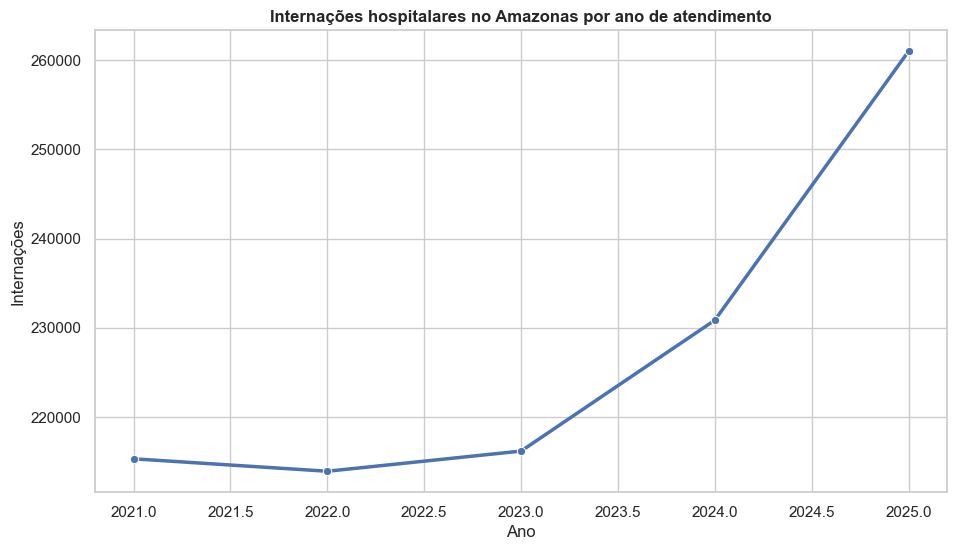

In [8]:
fig, ax = plt.subplots()
sns.lineplot(data=resumo_ano, x="ano", y="internacoes", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Internações hospitalares no Amazonas por ano de atendimento")
ax.set_xlabel("Ano")
ax.set_ylabel("Internações")
ax.ticklabel_format(style="plain", axis="y")
fig.savefig(PROCESSED_DIR / "internacoes_ano.png", dpi=150, bbox_inches="tight")
plt.show()

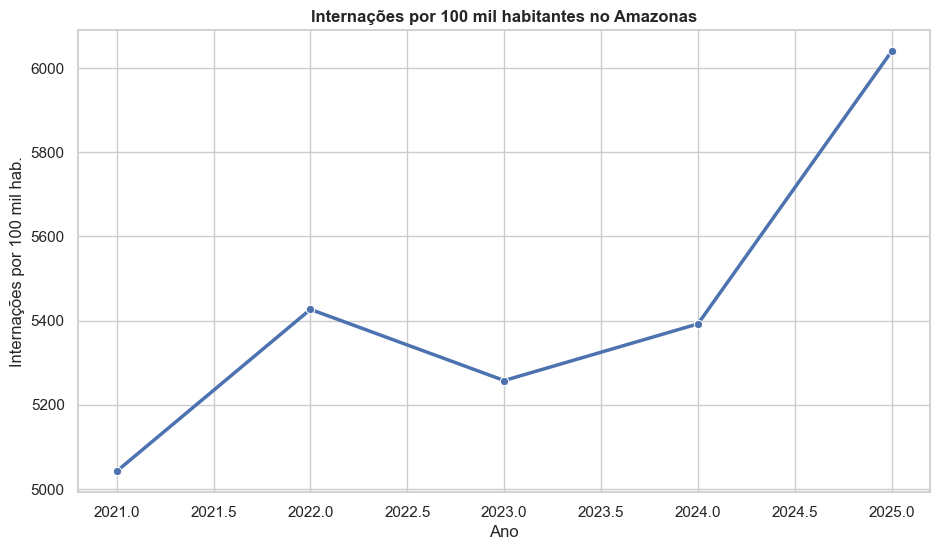

In [9]:
fig, ax = plt.subplots()
sns.lineplot(data=resumo_ano, x="ano", y="internacoes_por_100k", marker="o", linewidth=2.5, ax=ax)
ax.set_title("Internações por 100 mil habitantes no Amazonas")
ax.set_xlabel("Ano")
ax.set_ylabel("Internações por 100 mil hab.")
fig.savefig(PROCESSED_DIR / "internacoes_por_100k_ano.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise por município

In [10]:
top_municipios = (
    dados_municipio.groupby("municipio", as_index=False)
    .agg(internacoes=("internacoes", "sum"), obitos=("obitos", "sum"))
    .sort_values("internacoes", ascending=False)
    .head(10)
)
top_municipios["participacao_internacoes_%"] = (
    top_municipios["internacoes"] / dados_municipio["internacoes"].sum() * 100
)
top_municipios

,municipio,internacoes,obitos,participacao_internacoes_%
37,Manaus,600501,29011,52.805363
45,Parintins,39696,1166,3.490688
35,Manacapuru,34988,1055,3.076688
28,Itacoatiara,29979,998,2.636219
57,Tefe,28217,497,2.481276
19,Coari,23638,924,2.078620
40,Maues,17808,530,1.565956
25,Humaita,13945,368,1.226261
12,Boca Do Acre,12569,239,1.105261
38,Manicore,12161,284,1.069384


In [11]:
ranking_municipios = (
    dados_municipio.groupby("municipio", as_index=False)
    .agg(
        internacoes=("internacoes", "sum"),
        obitos=("obitos", "sum"),
        populacao_media=("populacao", "mean"),
        populacao_periodo=("populacao", "sum"),
    )
    .sort_values("internacoes", ascending=False)
    .reset_index(drop=True)
)
ranking_municipios["posicao"] = ranking_municipios.index + 1
ranking_municipios["participacao_%"] = ranking_municipios["internacoes"] / total_internacoes * 100
ranking_municipios["participacao_acumulada_%"] = ranking_municipios["participacao_%"].cumsum()
ranking_municipios["taxa_mortalidade"] = ranking_municipios["obitos"] / ranking_municipios["internacoes"] * 100

# Para o acumulado 2021-2025, o denominador populacional precisa acompanhar o período.
# A soma das populações anuais aproxima pessoas-ano e gera uma taxa anual média por 100 mil hab.
ranking_municipios["internacoes_por_100k"] = (
    ranking_municipios["internacoes"] / ranking_municipios["populacao_periodo"] * 100_000
)
ranking_municipios["obitos_por_100k"] = (
    ranking_municipios["obitos"] / ranking_municipios["populacao_periodo"] * 100_000
)

concentracao = pd.DataFrame(
    {
        "recorte": ["Top 1", "Top 5", "Top 10", "Demais municípios"],
        "participacao_%": [
            ranking_municipios.head(1)["participacao_%"].sum(),
            ranking_municipios.head(5)["participacao_%"].sum(),
            ranking_municipios.head(10)["participacao_%"].sum(),
            100 - ranking_municipios.head(10)["participacao_%"].sum(),
        ],
    }
)

concentracao

,recorte,participacao_%
0,Top 1,52.805363
1,Top 5,64.490233
2,Top 10,71.535715
3,Demais municípios,28.464285


## Volume absoluto x taxa populacional

Rankings por volume mostram onde a demanda hospitalar é maior em números absolutos. Já as taxas por 100 mil habitantes ajudam a enxergar municípios menores que podem ter pressão hospitalar proporcionalmente alta.

In [12]:
ranking_volume_vs_taxa = ranking_municipios.copy()
ranking_volume_vs_taxa["rank_volume"] = ranking_volume_vs_taxa["internacoes"].rank(
    ascending=False,
    method="first",
).astype(int)
ranking_volume_vs_taxa["rank_taxa_100k"] = ranking_volume_vs_taxa["internacoes_por_100k"].rank(
    ascending=False,
    method="first",
).astype(int)
ranking_volume_vs_taxa["diferenca_rank"] = (
    ranking_volume_vs_taxa["rank_volume"] - ranking_volume_vs_taxa["rank_taxa_100k"]
)

ranking_volume_vs_taxa.sort_values("rank_taxa_100k").head(10)

,municipio,internacoes,obitos,populacao_media,populacao_periodo,posicao,participacao_%,participacao_acumulada_%,taxa_mortalidade,internacoes_por_100k,obitos_por_100k,rank_volume,rank_taxa_100k,diferenca_rank
32,Anama,6082,22,10938.6,54693,33,0.534824,89.358396,0.361723,11120.253049,40.224526,33,1,32
46,Silves,4731,68,11570.6,57853,47,0.416023,95.824998,1.437328,8177.622595,117.539281,47,2,45
16,Ipixuna,10135,98,26290.8,131454,17,0.891226,78.110565,0.966946,7709.921341,74.550793,17,3,14
1,Parintins,39696,1166,103157.2,515786,2,3.490688,56.296051,2.937324,7696.215097,226.062747,2,4,-2
4,Tefe,28217,497,73761.6,368808,5,2.481276,64.490233,1.761350,7650.864406,134.758465,5,5,0
30,Anori,7046,54,18536.4,92682,31,0.619594,88.246715,0.766392,7602.339181,58.263741,31,6,25
8,Boca Do Acre,12569,239,36857.8,184289,9,1.105261,70.466331,1.901504,6820.265995,129.687610,9,7,2
33,Novo Airao,5813,111,17059.8,85299,34,0.511169,89.869565,1.909513,6814.851288,130.130482,34,8,26
31,Tonantins,6560,70,19700.4,98502,32,0.576857,88.823572,1.067073,6659.763254,71.064547,32,9,23
43,Uarini,4890,65,14808.4,74042,44,0.430005,94.565146,1.329243,6604.359688,87.788012,44,10,34


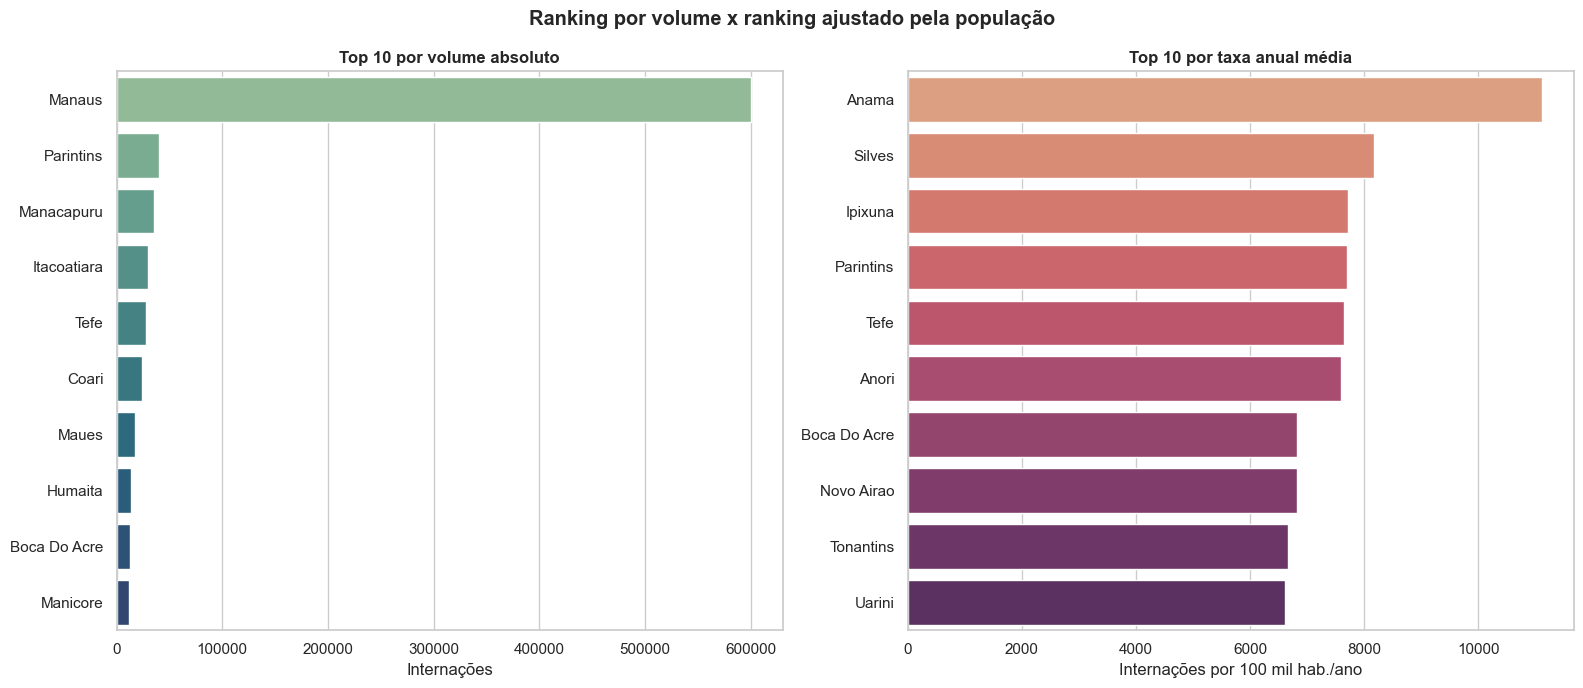

In [13]:
top_volume = ranking_volume_vs_taxa.nsmallest(10, "rank_volume").copy()
top_taxa = ranking_volume_vs_taxa.nsmallest(10, "rank_taxa_100k").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(
    data=top_volume,
    y="municipio",
    x="internacoes",
    hue="municipio",
    legend=False,
    palette="crest",
    ax=axes[0],
)
axes[0].set_title("Top 10 por volume absoluto")
axes[0].set_xlabel("Internações")
axes[0].set_ylabel("")
axes[0].ticklabel_format(style="plain", axis="x")

sns.barplot(
    data=top_taxa,
    y="municipio",
    x="internacoes_por_100k",
    hue="municipio",
    legend=False,
    palette="flare",
    ax=axes[1],
)
axes[1].set_title("Top 10 por taxa anual média")
axes[1].set_xlabel("Internações por 100 mil hab./ano")
axes[1].set_ylabel("")
fig.suptitle("Ranking por volume x ranking ajustado pela população", fontweight="bold")
fig.tight_layout()
fig.savefig(PROCESSED_DIR / "ranking_volume_vs_taxa.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura**

Manaus lidera em volume absoluto porque concentra população e capacidade assistencial. Quando o denominador populacional entra na análise, municípios menores podem subir no ranking, sinalizando pressão proporcionalmente alta. Essa comparação é mais adequada para levantar hipóteses de acesso, referência regional e necessidade de investigação local.

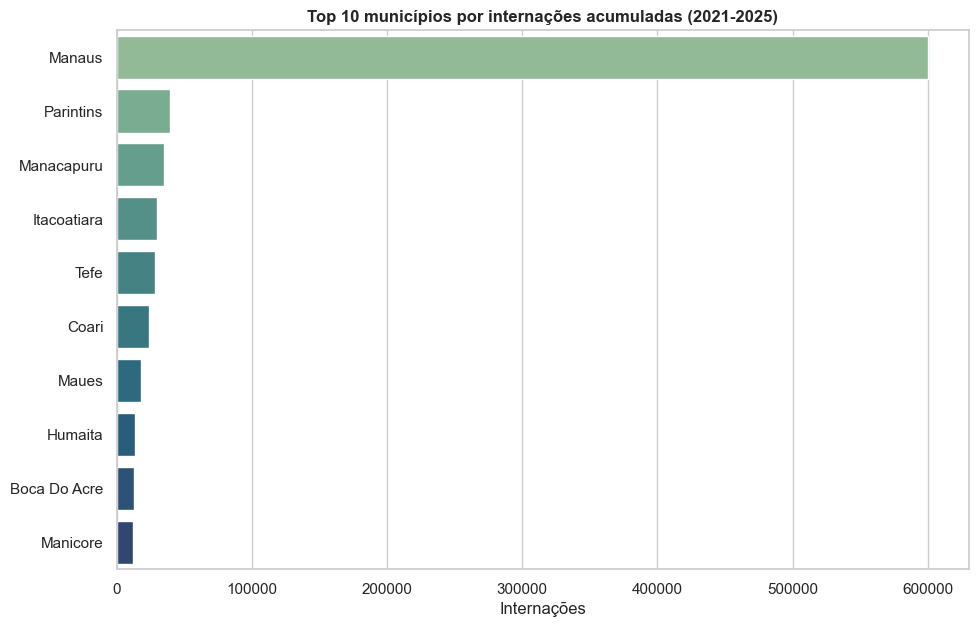

In [14]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=top_municipios,
    y="municipio",
    x="internacoes",
    hue="municipio",
    legend=False,
    palette="crest",
    ax=ax,
)
ax.set_title("Top 10 municípios por internações acumuladas (2021-2025)")
ax.set_xlabel("Internações")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
fig.savefig(PROCESSED_DIR / "internacoes_municipio.png", dpi=150, bbox_inches="tight")
plt.show()

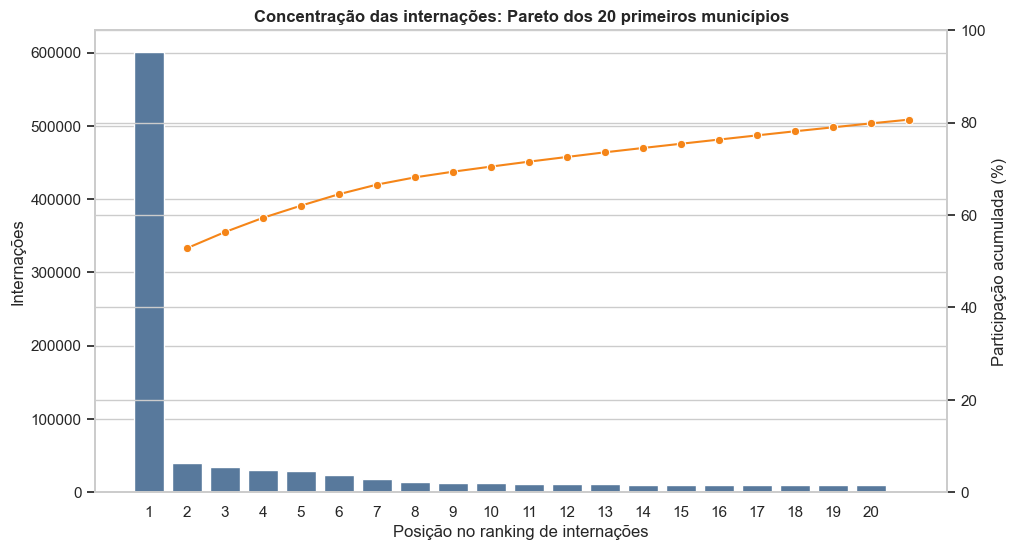

In [15]:
fig, ax1 = plt.subplots(figsize=(11, 6))
pareto = ranking_municipios.head(20).copy()

sns.barplot(
    data=pareto,
    x="posicao",
    y="internacoes",
    color="#4C78A8",
    ax=ax1,
)
ax1.set_title("Concentração das internações: Pareto dos 20 primeiros municípios")
ax1.set_xlabel("Posição no ranking de internações")
ax1.set_ylabel("Internações")
ax1.ticklabel_format(style="plain", axis="y")

ax2 = ax1.twinx()
sns.lineplot(
    data=pareto,
    x="posicao",
    y="participacao_acumulada_%",
    marker="o",
    color="#F58518",
    ax=ax2,
)
ax2.set_ylabel("Participação acumulada (%)")
ax2.set_ylim(0, 100)
fig.savefig(PROCESSED_DIR / "pareto_municipios.png", dpi=150, bbox_inches="tight")
plt.show()

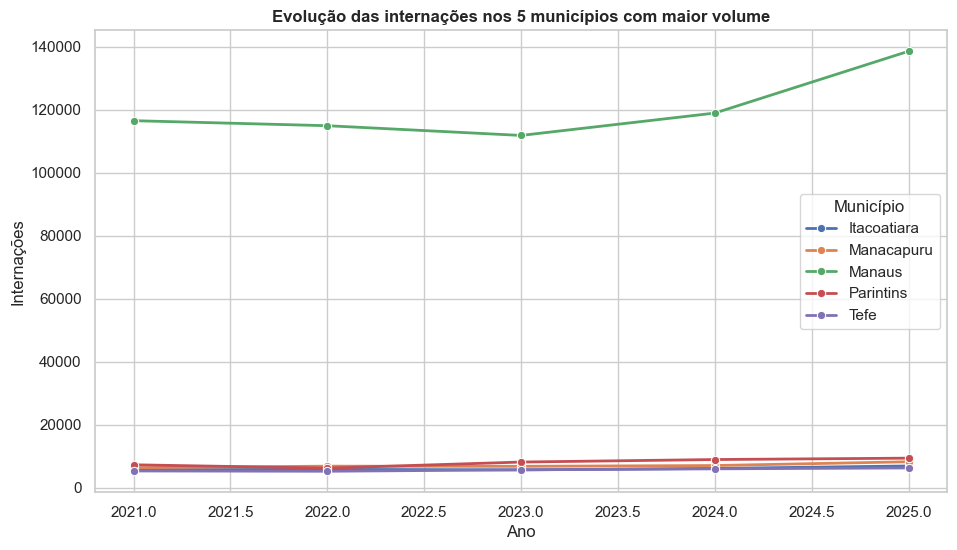

In [16]:
top5 = top_municipios["municipio"].head(5)
serie_top5 = dados_municipio[dados_municipio["municipio"].isin(top5)]

fig, ax = plt.subplots()
sns.lineplot(
    data=serie_top5,
    x="ano",
    y="internacoes",
    hue="municipio",
    marker="o",
    linewidth=2,
    ax=ax,
)
ax.set_title("Evolução das internações nos 5 municípios com maior volume")
ax.set_xlabel("Ano")
ax.set_ylabel("Internações")
ax.ticklabel_format(style="plain", axis="y")
plt.legend(title="Município")
fig.savefig(PROCESSED_DIR / "evolucao_top5_municipios.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
crescimento_municipios = (
    dados_municipio.pivot_table(
        index="municipio",
        columns="ano",
        values="internacoes",
        aggfunc="sum",
    )
    .reset_index()
)
crescimento_municipios["variacao_abs_2021_2025"] = crescimento_municipios[2025] - crescimento_municipios[2021]
crescimento_municipios["variacao_%_2021_2025"] = np.where(
    crescimento_municipios[2021] > 0,
    (crescimento_municipios[2025] / crescimento_municipios[2021] - 1) * 100,
    np.nan,
)
crescimento_municipios = crescimento_municipios.sort_values("variacao_abs_2021_2025", ascending=False)

crescimento_municipios.head(10)

ano,municipio,2021,2022,2023,2024,2025,variacao_abs_2021_2025,variacao_%_2021_2025
37,Manaus,116465,114869,111780,118880,138507,22042,18.925858
45,Parintins,7223,6162,8092,8890,9329,2106,29.156860
35,Manacapuru,6299,6785,6733,6987,8184,1885,29.925385
26,Ipixuna,1109,1785,2407,2537,2297,1188,107.123535
28,Itacoatiara,5686,5760,5619,6067,6847,1161,20.418572
9,Benjamin Constant,1657,982,1760,2014,2795,1138,68.678334
3,Anori,818,731,1982,1658,1857,1039,127.017115
57,Tefe,5265,5171,5621,5938,6222,957,18.176638
2,Anama,649,781,1387,1724,1541,892,137.442219
19,Coari,4516,4501,4522,4823,5276,760,16.829052


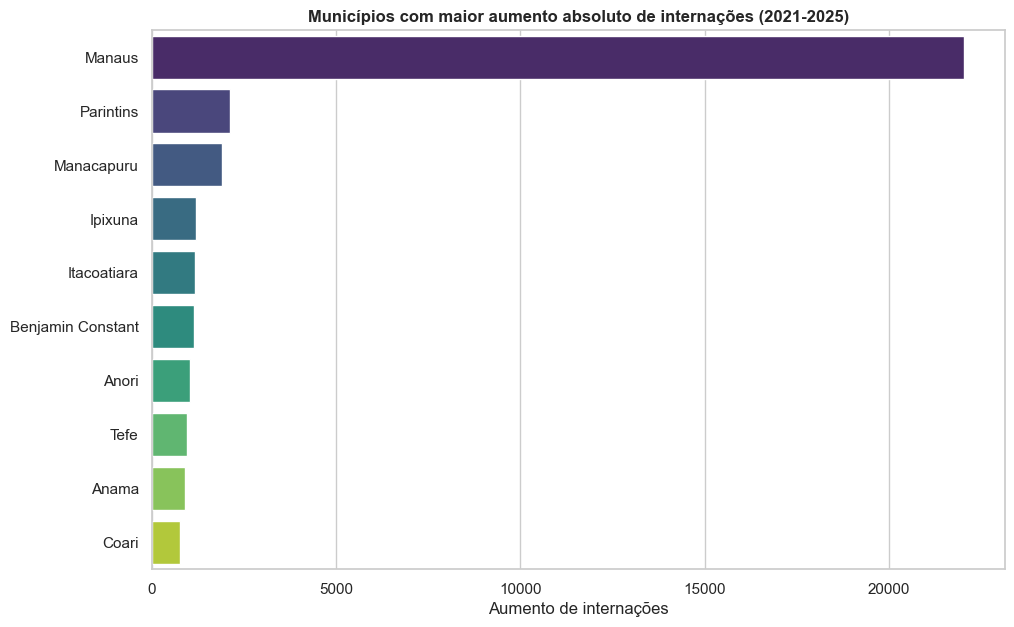

In [18]:
top_crescimento_abs = crescimento_municipios.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=top_crescimento_abs,
    y="municipio",
    x="variacao_abs_2021_2025",
    hue="municipio",
    legend=False,
    palette="viridis",
    ax=ax,
)
ax.set_title("Municípios com maior aumento absoluto de internações (2021-2025)")
ax.set_xlabel("Aumento de internações")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
fig.savefig(PROCESSED_DIR / "crescimento_municipios.png", dpi=150, bbox_inches="tight")
plt.show()

## Análise por faixa etária

In [19]:
resumo_faixa = (
    internacoes_faixa.groupby("faixa_etaria", observed=True, as_index=False)
    .agg(internacoes=("internacoes", "sum"))
    .sort_values("faixa_etaria")
)
resumo_faixa["participacao_%"] = resumo_faixa["internacoes"] / resumo_faixa["internacoes"].sum() * 100
resumo_faixa

,faixa_etaria,internacoes,participacao_%
0,Menor 1 ano,73491,6.462469
1,1 a 4 anos,65647,5.772703
2,5 a 9 anos,39161,3.443643
3,10 a 14 anos,32752,2.880064
4,15 a 19 anos,99977,8.791529
5,20 a 29 anos,251760,22.138644
6,30 a 39 anos,166569,14.647330
7,40 a 49 anos,111750,9.826793
8,50 a 59 anos,94284,8.290912
9,60 a 69 anos,94774,8.334000


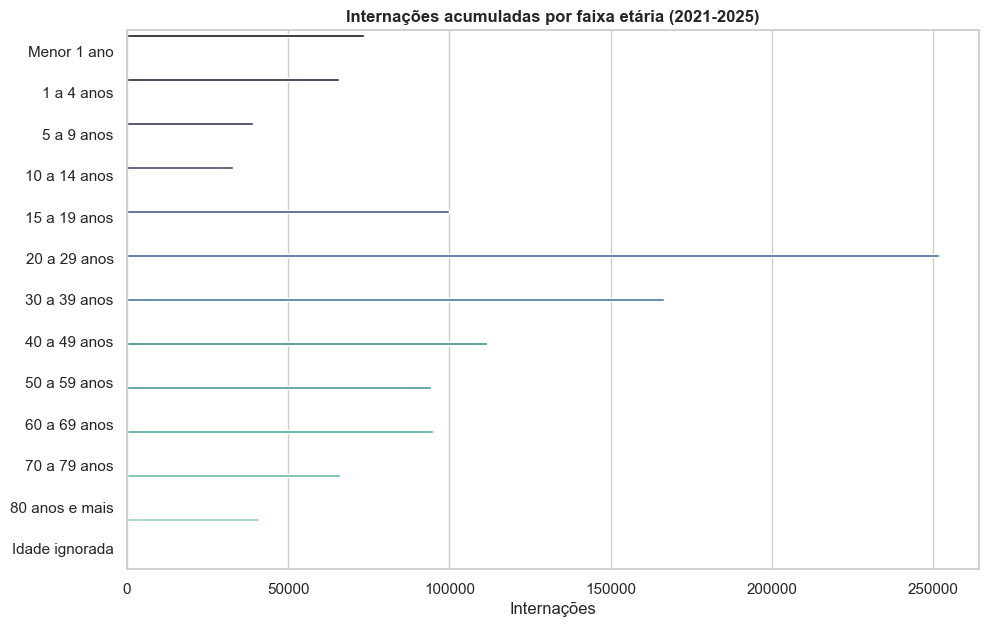

In [20]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=resumo_faixa,
    y="faixa_etaria",
    x="internacoes",
    hue="faixa_etaria",
    legend=False,
    palette="mako",
    ax=ax,
)
ax.set_title("Internações acumuladas por faixa etária (2021-2025)")
ax.set_xlabel("Internações")
ax.set_ylabel("")
ax.ticklabel_format(style="plain", axis="x")
fig.savefig(PROCESSED_DIR / "internacoes_faixa_etaria.png", dpi=150, bbox_inches="tight")
plt.show()

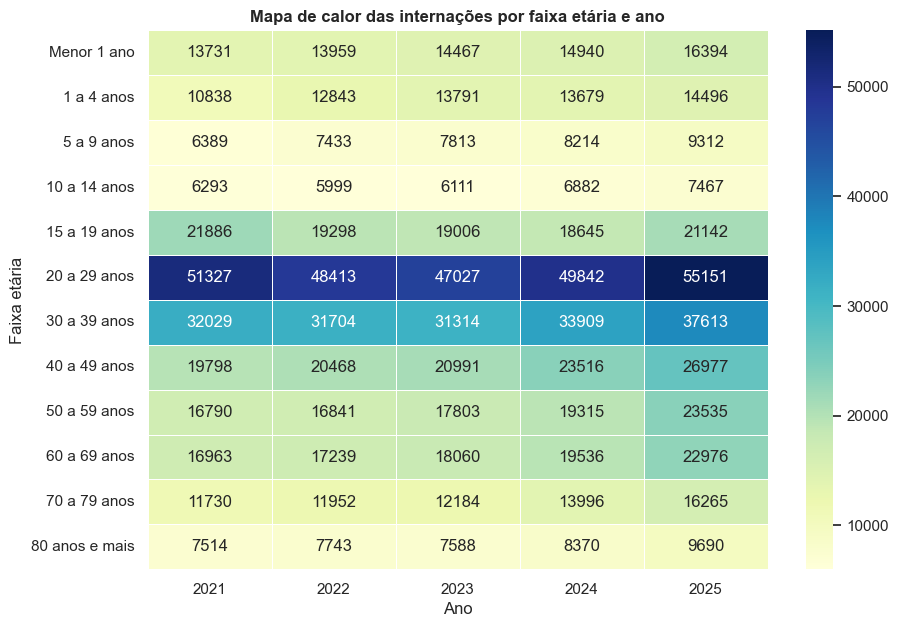

In [21]:
matriz_faixa_ano = (
    internacoes_faixa.pivot_table(
        index="faixa_etaria",
        columns="ano",
        values="internacoes",
        aggfunc="sum",
        observed=True,
    )
    .reindex(faixa_ordem)
    .dropna(how="all")
)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(matriz_faixa_ano, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=0.5, ax=ax)
ax.set_title("Mapa de calor das internações por faixa etária e ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Faixa etária")
fig.savefig(PROCESSED_DIR / "heatmap_faixa_ano.png", dpi=150, bbox_inches="tight")
plt.show()

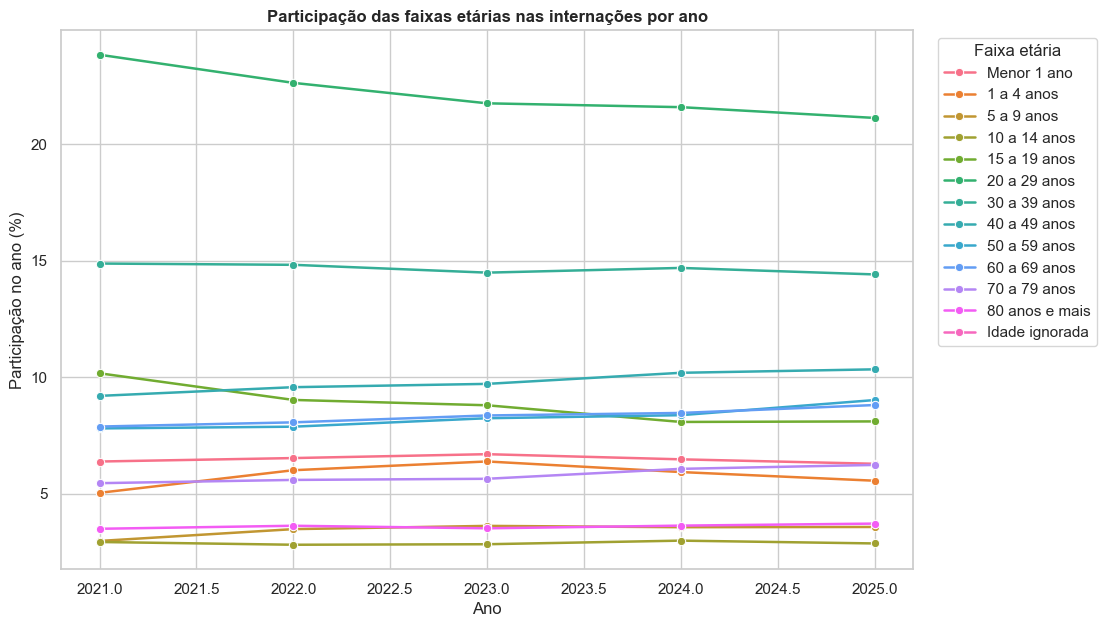

In [22]:
composicao_faixa_ano = internacoes_faixa.copy()
composicao_faixa_ano["participacao_ano_%"] = (
    composicao_faixa_ano["internacoes"]
    / composicao_faixa_ano.groupby("ano", observed=True)["internacoes"].transform("sum")
    * 100
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.lineplot(
    data=composicao_faixa_ano,
    x="ano",
    y="participacao_ano_%",
    hue="faixa_etaria",
    marker="o",
    linewidth=1.8,
    ax=ax,
)
ax.set_title("Participação das faixas etárias nas internações por ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Participação no ano (%)")
plt.legend(title="Faixa etária", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(PROCESSED_DIR / "composicao_faixa_ano.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura**

As faixas de 20 a 39 anos têm maior volume absoluto de internações, mas a análise de mortalidade mostra outra dimensão do problema: volume e gravidade não apontam necessariamente para os mesmos grupos.

## Mortalidade

In [23]:
taxa_faixa_ponderada = taxa_faixa.merge(
    internacoes_faixa,
    on=["faixa_etaria", "ano"],
    how="left",
)
taxa_faixa_ponderada["obitos_estimados"] = (
    taxa_faixa_ponderada["taxa_mortalidade"]
    / 100
    * taxa_faixa_ponderada["internacoes"]
)

taxa_media_faixa = (
    taxa_faixa_ponderada.groupby("faixa_etaria", observed=True, as_index=False)
    .agg(
        internacoes=("internacoes", "sum"),
        obitos_estimados=("obitos_estimados", "sum"),
    )
    .sort_values("faixa_etaria")
)
taxa_media_faixa["taxa_mortalidade_ponderada"] = (
    taxa_media_faixa["obitos_estimados"] / taxa_media_faixa["internacoes"] * 100
)
taxa_media_faixa

,faixa_etaria,internacoes,obitos_estimados,taxa_mortalidade_ponderada
0,Menor 1 ano,73491,2151.6138,2.927724
1,1 a 4 anos,65647,436.7275,0.665267
2,5 a 9 anos,39161,211.5085,0.540100
3,10 a 14 anos,32752,222.6971,0.679950
4,15 a 19 anos,99977,402.2609,0.402353
5,20 a 29 anos,251760,1562.1925,0.620509
6,30 a 39 anos,166569,2255.6781,1.354200
7,40 a 49 anos,111750,3754.3610,3.359607
8,50 a 59 anos,94284,5606.4002,5.946290
9,60 a 69 anos,94774,8152.2007,8.601727


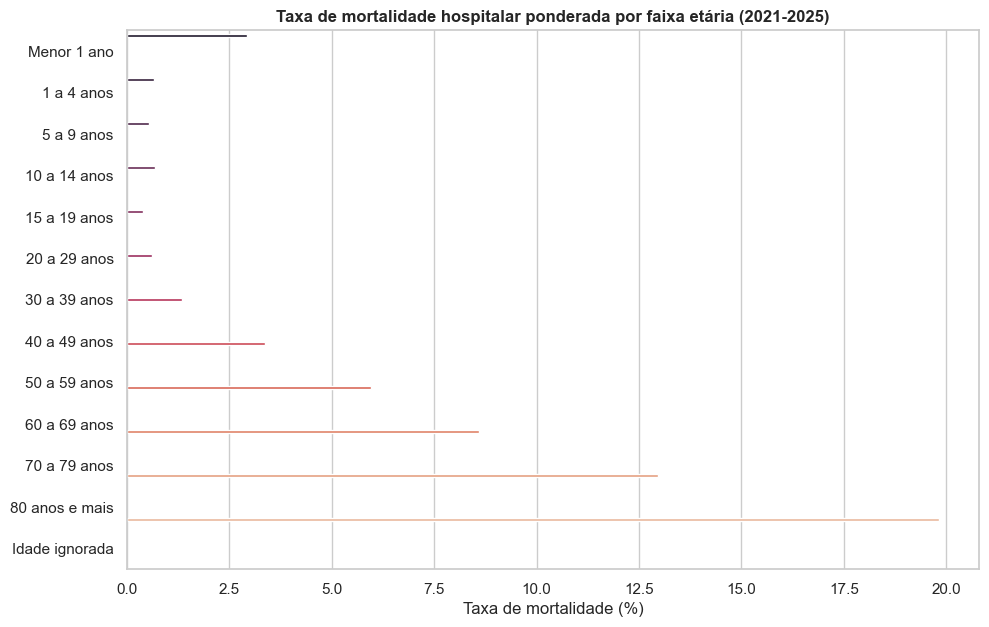

In [24]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(
    data=taxa_media_faixa,
    y="faixa_etaria",
    x="taxa_mortalidade_ponderada",
    hue="faixa_etaria",
    legend=False,
    palette="rocket",
    ax=ax,
)
ax.set_title("Taxa de mortalidade hospitalar ponderada por faixa etária (2021-2025)")
ax.set_xlabel("Taxa de mortalidade (%)")
ax.set_ylabel("")
fig.savefig(PROCESSED_DIR / "taxa_mortalidade_faixa_etaria.png", dpi=150, bbox_inches="tight")
plt.show()

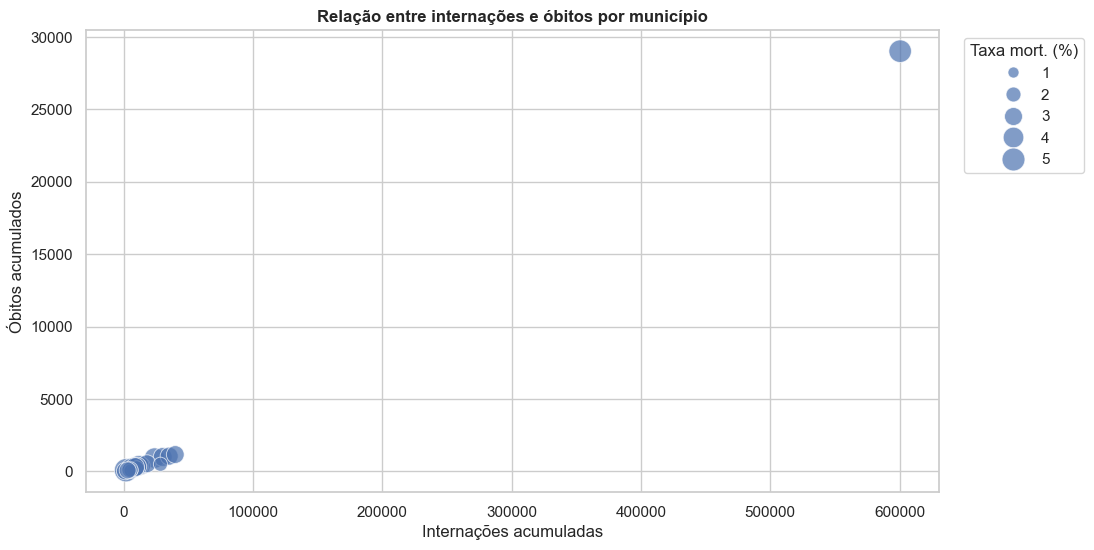

In [25]:
dados_municipio_total = (
    dados_municipio.groupby("municipio", as_index=False)
    .agg(internacoes=("internacoes", "sum"), obitos=("obitos", "sum"))
)
dados_municipio_total["taxa_mortalidade"] = (
    dados_municipio_total["obitos"] / dados_municipio_total["internacoes"] * 100
)

fig, ax = plt.subplots()
sns.scatterplot(
    data=dados_municipio_total,
    x="internacoes",
    y="obitos",
    size="taxa_mortalidade",
    sizes=(30, 280),
    alpha=0.7,
    ax=ax,
)
ax.set_title("Relação entre internações e óbitos por município")
ax.set_xlabel("Internações acumuladas")
ax.set_ylabel("Óbitos acumulados")
ax.ticklabel_format(style="plain")
plt.legend(title="Taxa mort. (%)", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(PROCESSED_DIR / "internacoes_obitos_municipio.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
municipios_matriz = dados_municipio_total[dados_municipio_total["internacoes"] >= 1000].copy()
municipios_matriz["grupo_volume"] = np.where(
    municipios_matriz["internacoes"] >= municipios_matriz["internacoes"].median(),
    "Maior volume",
    "Menor volume",
)
municipios_matriz["grupo_mortalidade"] = np.where(
    municipios_matriz["taxa_mortalidade"] >= municipios_matriz["taxa_mortalidade"].median(),
    "Maior mortalidade",
    "Menor mortalidade",
)
municipios_matriz["quadrante"] = municipios_matriz["grupo_volume"] + " / " + municipios_matriz["grupo_mortalidade"]

municipios_matriz.sort_values("taxa_mortalidade", ascending=False).head(10)

,municipio,internacoes,obitos,taxa_mortalidade,grupo_volume,grupo_mortalidade,quadrante
18,Careiro Da Varzea,1586,82,5.170240,Menor volume,Maior mortalidade,Menor volume / Maior mortalidade
37,Manaus,600501,29011,4.831133,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
19,Coari,23638,924,3.908960,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
48,Rio Preto Da Eva,5790,220,3.799655,Menor volume,Maior mortalidade,Menor volume / Maior mortalidade
27,Iranduba,11548,423,3.662972,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
47,Presidente Figueiredo,7830,286,3.652618,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
55,Tabatinga,8587,293,3.412135,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
28,Itacoatiara,29979,998,3.328997,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
51,Sao Gabriel Da Cachoeira,10296,336,3.263403,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade
21,Eirunepe,8518,266,3.122799,Maior volume,Maior mortalidade,Maior volume / Maior mortalidade


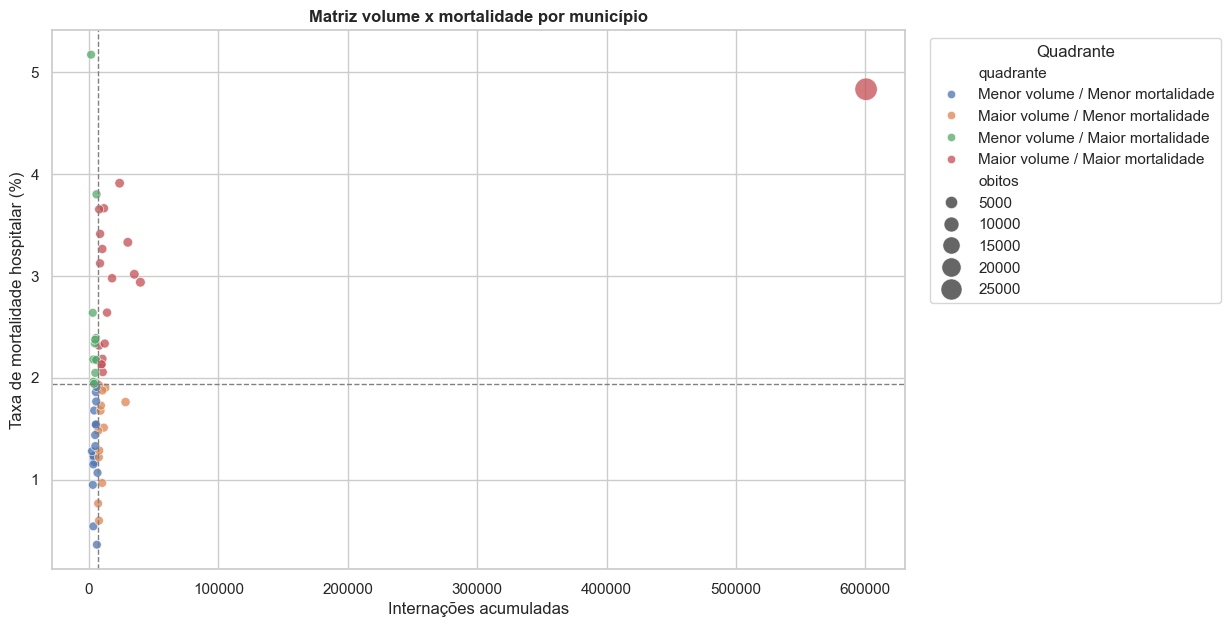

In [27]:
fig, ax = plt.subplots(figsize=(11, 7))
sns.scatterplot(
    data=municipios_matriz,
    x="internacoes",
    y="taxa_mortalidade",
    hue="quadrante",
    size="obitos",
    sizes=(40, 260),
    alpha=0.75,
    ax=ax,
)
ax.axvline(municipios_matriz["internacoes"].median(), color="gray", linestyle="--", linewidth=1)
ax.axhline(municipios_matriz["taxa_mortalidade"].median(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Matriz volume x mortalidade por município")
ax.set_xlabel("Internações acumuladas")
ax.set_ylabel("Taxa de mortalidade hospitalar (%)")
ax.ticklabel_format(style="plain", axis="x")
plt.legend(title="Quadrante", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.savefig(PROCESSED_DIR / "matriz_volume_mortalidade.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura**

A matriz ajuda a evitar uma conclusão superficial. Municípios com muitas internações tendem a concentrar óbitos em números absolutos, mas municípios com menor volume podem apresentar taxas de mortalidade proporcionalmente altas. Para uma avaliação de gestão, esses casos seriam bons candidatos a investigação qualitativa: perfil dos hospitais, distância até serviços de maior complexidade, composição etária e tipos de diagnóstico.

## Exportação final

Os arquivos abaixo deixam explícita a transformação de dados: os CSVs originais ficam em `data/raw/`, enquanto estes arquivos tratados ficam em `data/processed/`.

In [28]:
dados_municipio.to_csv(PROCESSED_DIR / "municipios_tratados.csv", index=False)
resumo_faixa.to_csv(PROCESSED_DIR / "resumo_faixa_etaria.csv", index=False)
resumo_ano.to_csv(PROCESSED_DIR / "resumo_ano.csv", index=False)
ranking_municipios.to_csv(PROCESSED_DIR / "ranking_municipios.csv", index=False)
ranking_volume_vs_taxa.to_csv(PROCESSED_DIR / "ranking_volume_vs_taxa.csv", index=False)
concentracao.to_csv(PROCESSED_DIR / "concentracao_municipios.csv", index=False)
crescimento_municipios.to_csv(PROCESSED_DIR / "crescimento_municipios.csv", index=False)
municipios_matriz.to_csv(PROCESSED_DIR / "matriz_volume_mortalidade.csv", index=False)
taxa_media_faixa.to_csv(PROCESSED_DIR / "resumo_taxa_mortalidade_faixa.csv", index=False)

sorted(path.name for path in PROCESSED_DIR.glob("*"))

['composicao_faixa_ano.png',
 'concentracao_municipios.csv',
 'crescimento_municipios.csv',
 'crescimento_municipios.png',
 'evolucao_top5_municipios.png',
 'heatmap_faixa_ano.png',
 'internacoes_ano.png',
 'internacoes_faixa_etaria.png',
 'internacoes_faixa_etaria_ano_am_limpo.csv',
 'internacoes_municipio.png',
 'internacoes_obitos_municipio.png',
 'internacoes_obitos_municipio_ano_am_limpo.csv',
 'internacoes_por_100k_ano.png',
 'matriz_volume_mortalidade.csv',
 'matriz_volume_mortalidade.png',
 'municipios_tratados.csv',
 'pareto_municipios.png',
 'populacao_municipios_am_tratada.csv',
 'ranking_municipios.csv',
 'ranking_volume_vs_taxa.csv',
 'ranking_volume_vs_taxa.png',
 'resumo_ano.csv',
 'resumo_faixa_etaria.csv',
 'resumo_taxa_mortalidade_faixa.csv',
 'taxa_mortalidade_faixa_etaria.png',
 'taxa_mortalidade_faixa_etaria_ano_am_limpo.csv']

## O que os dados revelam?

Entre 2021 e 2025, os dados do SIH/SUS indicam **1.137.197 internações hospitalares** de residentes no Amazonas. O volume anual ficou relativamente estável entre 2021 e 2023, cresceu em 2024 e atingiu o maior valor em 2025, com alta de aproximadamente **21,2%** em relação a 2021.

A distribuição municipal é bastante concentrada: **Manaus responde por cerca de 52,8% das internações** do período, seguida por Parintins, Manacapuru, Itacoatiara e Tefé. O gráfico de Pareto mostra que poucos municípios concentram grande parte da demanda, o que combina peso populacional, centralidade da rede assistencial e possíveis fluxos de atendimento para polos regionais.

Ao integrar a população municipal do IBGE, o ranking por internações por 100 mil habitantes muda a leitura: municípios menores podem apresentar pressão proporcionalmente alta mesmo sem aparecerem entre os maiores volumes absolutos. Esse recorte torna a análise mais justa para comparar territórios de tamanhos diferentes.

Por idade, as faixas de **20 a 29 anos** e **30 a 39 anos** concentram o maior número de internações. Sem cruzar com sexo, diagnóstico ou procedimento, não dá para afirmar a causa, mas o padrão sugere investigar eventos ligados ao ciclo reprodutivo, causas clínicas frequentes em adultos jovens e acesso hospitalar por perfil demográfico.

A mortalidade hospitalar cresce com a idade. As maiores taxas médias aparecem em **80 anos e mais**, **70 a 79 anos** e **60 a 69 anos**, o que é coerente com maior fragilidade clínica e maior gravidade esperada das internações em idosos. Já a matriz volume x mortalidade mostra que o maior número absoluto de óbitos não deve ser confundido com maior taxa proporcional: são leituras complementares.

Como o TABNET agrega dados de internações do SUS, os resultados não representam toda a morbidade da população nem internações exclusivamente privadas. Ainda assim, revelam um retrato útil da demanda hospitalar pública e conveniada no Amazonas, com evidências claras de concentração territorial, crescimento recente das internações e maior mortalidade proporcional nas faixas etárias idosas.

## Próximos passos analíticos

Para aprofundar este EDA, os próximos recortes mais relevantes seriam cruzar município e faixa etária com sexo, capítulo CID-10, lista de morbidade e caráter de atendimento. Também seria útil comparar Amazonas com outros estados da região Norte e transformar os principais indicadores em um painel interativo.